In [63]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/jeandedieunyandwi/lending-club-dataset/lending_club_loan_two.csv


In [64]:
import pandas as pd
import numpy as np

file_path = "/kaggle/input/datasets/jeandedieunyandwi/lending-club-dataset/lending_club_loan_two.csv"
raw_df = pd.read_csv(file_path)

print(raw_df.shape)
print(raw_df.columns.tolist())
raw_df.head()

(396030, 27)
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'title', 'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'address']


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [65]:
print(" BASIC INFO ")
print(raw_df.shape)

print("\n DATA TYPES ")
print(raw_df.dtypes)

print("\n MISSING VALUES ")
print(raw_df.isnull().sum().sort_values(ascending=False))

print("\n LOAN STATUS DISTRIBUTION ")
print(raw_df['loan_status'].value_counts())

 BASIC INFO 
(396030, 27)

 DATA TYPES 
loan_amnt               float64
term                     object
int_rate                float64
installment             float64
grade                    object
sub_grade                object
emp_title                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
issue_d                  object
loan_status              object
purpose                  object
title                    object
dti                     float64
earliest_cr_line         object
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status      object
application_type         object
mort_acc                float64
pub_rec_bankruptcies    float64
address                  object
dtype: object

 MISSING VALUES 
mort_acc                37795
emp_title               22927
emp_

In [66]:
df = raw_df.copy()

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

df['target'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

print(df[['loan_status', 'target']].head())
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True) * 100)

   loan_status  target
0   Fully Paid       0
1   Fully Paid       0
2   Fully Paid       0
3   Fully Paid       0
4  Charged Off       1
target
0    318357
1     77673
Name: count, dtype: int64
target
0    80.387092
1    19.612908
Name: proportion, dtype: float64


In [67]:
# term: "36 months" -> 36
df['term'] = df['term'].astype(str).str.strip().str.extract(r'(\d+)')[0].astype(float)

# emp_length: "10+ years", "< 1 year" -> numeric years
df['emp_length'] = df['emp_length'].astype(str).str.strip()

# handle special cases first
df['emp_length'] = df['emp_length'].replace({
    '< 1 year': '0',
    '10+ years': '10',
    'nan': np.nan
})

df['emp_length'] = df['emp_length'].str.extract(r'(\d+)')[0]
df['emp_length'] = df['emp_length'].fillna(0).astype(float)

# sub_grade: B4 -> 4
df['sub_grade_num'] = df['sub_grade'].astype(str).str.extract(r'(\d+)')[0].astype(float)

# grade: A-G -> 1-7
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_num'] = df['grade'].map(grade_map).astype(float)

# issue_d and earliest_cr_line as dates
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce')

# extract useful date features
df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month

df['earliest_credit_year'] = df['earliest_cr_line'].dt.year
df['credit_history_age'] = df['issue_year'] - df['earliest_credit_year']

/tmp/ipykernel_92/1484521952.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
/tmp/ipykernel_92/1484521952.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce')


In [68]:
drop_cols = [
    'loan_status',        # original target text
    'emp_title',          # too many unique values
    'title',              # noisy text
    'address',            # noisy full address
    'grade',              # replaced by grade_num
    'sub_grade',          # replaced by sub_grade_num
    'issue_d',            # replaced by issue_year, issue_month
    'earliest_cr_line'    # replaced by earliest_credit_year, credit_history_age
]

df = df.drop(columns=drop_cols)

print(df.columns.tolist())
print(df.shape)

['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'target', 'sub_grade_num', 'grade_num', 'issue_year', 'issue_month', 'earliest_credit_year', 'credit_history_age']
(396030, 26)


In [69]:
for col in ['mort_acc', 'revol_util', 'pub_rec_bankruptcies']:
    if col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# final missing check
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

Series([], dtype: int64)


In [70]:
df = pd.get_dummies(df, drop_first=True)

# convert bool columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print("Object columns left:", df.select_dtypes(include='object').columns.tolist())
print(df.shape)

Object columns left: []
(396030, 44)


In [71]:
X = df.drop('target', axis=1)
y = df['target']

print(X.shape, y.shape)
print(y.value_counts())

(396030, 43) (396030,)
target
0    318357
1     77673
Name: count, dtype: int64


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(316824, 43) (79206, 43)
target
0    0.803872
1    0.196128
Name: proportion, dtype: float64
target
0    0.803866
1    0.196134
Name: proportion, dtype: float64


In [73]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:")
print(y_train_res.value_counts())

Before SMOTE: target
0    254686
1     62138
Name: count, dtype: int64
After SMOTE:
target
0    254686
1    254686
Name: count, dtype: int64


In [74]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_model.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=2000)

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [76]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n {name} ")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
evaluate_model(rf_model, X_test, y_test, "Random Forest")


 Logistic Regression 
Confusion Matrix:
[[42627 21044]
 [ 6214  9321]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.67      0.76     63671
           1       0.31      0.60      0.41     15535

    accuracy                           0.66     79206
   macro avg       0.59      0.63      0.58     79206
weighted avg       0.76      0.66      0.69     79206

ROC-AUC: 0.6883704808225796

 Random Forest 
Confusion Matrix:
[[61858  1813]
 [13601  1934]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89     63671
           1       0.52      0.12      0.20     15535

    accuracy                           0.81     79206
   macro avg       0.67      0.55      0.54     79206
weighted avg       0.76      0.81      0.75     79206

ROC-AUC: 0.7131251092596383


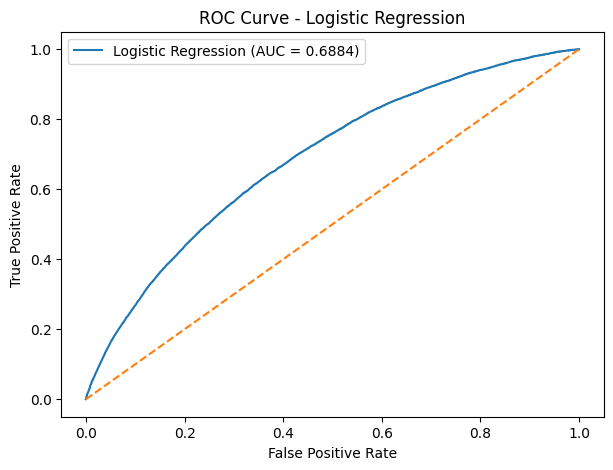

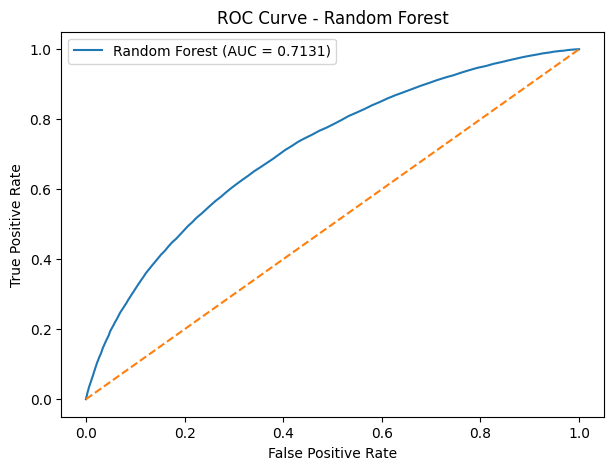

In [77]:
import matplotlib.pyplot as plt
def plot_roc(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

plot_roc(lr_model, X_test, y_test, "Logistic Regression")
plot_roc(rf_model, X_test, y_test, "Random Forest")

In [78]:
feature_importance = pd.DataFrame({
    'feature': X_train_res.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(20))

                    feature  importance
15                grade_num    0.147458
1                      term    0.069994
2                  int_rate    0.068611
14            sub_grade_num    0.048846
6                       dti    0.041980
4                emp_length    0.041182
12                 mort_acc    0.037992
20  home_ownership_MORTGAGE    0.035842
10               revol_util    0.035296
5                annual_inc    0.035174
9                 revol_bal    0.034502
3               installment    0.033770
24      home_ownership_RENT    0.030623
0                 loan_amnt    0.029490
7                  open_acc    0.029399
11                total_acc    0.029134
17              issue_month    0.025553
16               issue_year    0.024335
18     earliest_credit_year    0.023879
19       credit_history_age    0.023631


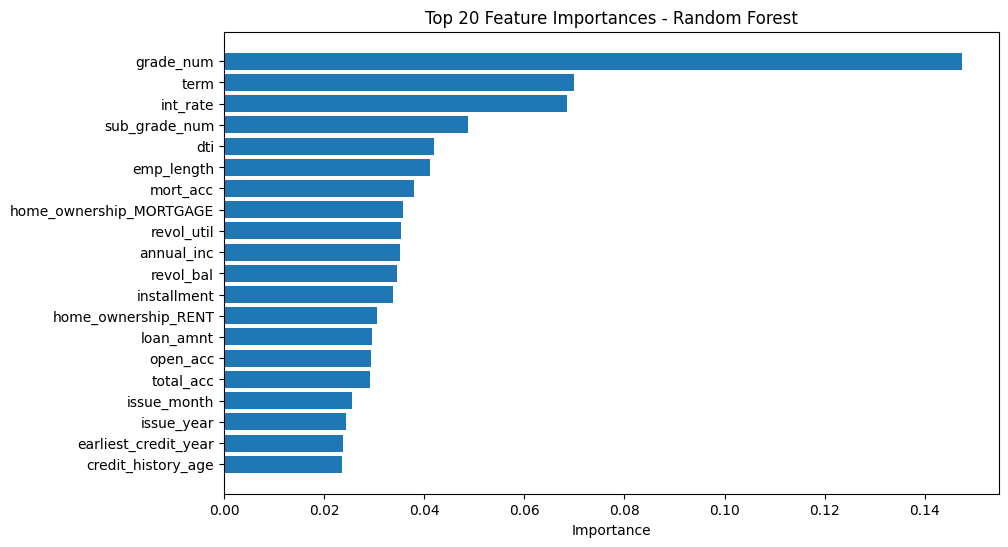

In [79]:
top_n = 20
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances - Random Forest")
plt.show()

In [80]:
def risk_category(prob):
    if prob < 0.40:
        return "Low Risk"
    elif prob < 0.60:
        return "Medium Risk"
    return "High Risk"

In [81]:
import joblib

joblib.dump(rf_model, "credit_risk_random_forest.pkl")
joblib.dump(X.columns.tolist(), "model_features.pkl")

print("Model saved successfully.")

Model saved successfully.


In [82]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight={0:1, 1:3},  # improve recall
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight={0: 1, 1: 3}, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [83]:
y_prob = rf_model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.3).astype(int)

In [84]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[51606 12065]
 [ 8266  7269]]
              precision    recall  f1-score   support

           0       0.86      0.81      0.84     63671
           1       0.38      0.47      0.42     15535

    accuracy                           0.74     79206
   macro avg       0.62      0.64      0.63     79206
weighted avg       0.77      0.74      0.75     79206



In [85]:
from xgboost import XGBClassifier
import shap

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [86]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 4.098715761691718


In [87]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

# train on original split first
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [88]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

print(" XGBoost (threshold = 0.5) ")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

 XGBoost (threshold = 0.5) 
Confusion Matrix:
[[42941 20730]
 [ 5163 10372]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.67      0.77     63671
           1       0.33      0.67      0.44     15535

    accuracy                           0.67     79206
   macro avg       0.61      0.67      0.61     79206
weighted avg       0.78      0.67      0.70     79206

ROC-AUC: 0.7337899485373993


In [89]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    print(f"\n Threshold: {t} ")
    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))


 Threshold: 0.2 
[[ 9198 54473]
 [  365 15170]]
              precision    recall  f1-score   support

           0       0.96      0.14      0.25     63671
           1       0.22      0.98      0.36     15535

    accuracy                           0.31     79206
   macro avg       0.59      0.56      0.30     79206
weighted avg       0.82      0.31      0.27     79206


 Threshold: 0.3 
[[20211 43460]
 [ 1330 14205]]
              precision    recall  f1-score   support

           0       0.94      0.32      0.47     63671
           1       0.25      0.91      0.39     15535

    accuracy                           0.43     79206
   macro avg       0.59      0.62      0.43     79206
weighted avg       0.80      0.43      0.46     79206


 Threshold: 0.4 
[[32182 31489]
 [ 2964 12571]]
              precision    recall  f1-score   support

           0       0.92      0.51      0.65     63671
           1       0.29      0.81      0.42     15535

    accuracy                       

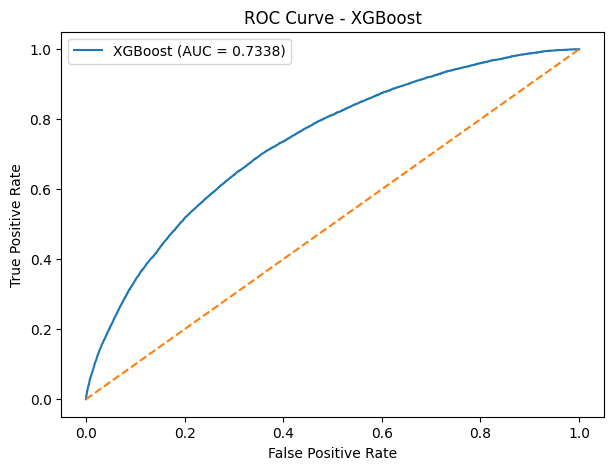

In [90]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
auc = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

In [91]:
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(xgb_importance.head(20))

                                feature  importance
15                            grade_num    0.533270
1                                  term    0.066214
2                              int_rate    0.031051
16                           issue_year    0.027046
20              home_ownership_MORTGAGE    0.022811
24                  home_ownership_RENT    0.017817
17                          issue_month    0.017706
6                                   dti    0.016799
37               purpose_small_business    0.016702
14                        sub_grade_num    0.016187
12                             mort_acc    0.015029
5                            annual_inc    0.014387
27                  purpose_credit_card    0.010704
4                            emp_length    0.010355
0                             loan_amnt    0.009200
25  verification_status_Source Verified    0.008700
3                           installment    0.008662
10                           revol_util    0.008332
39          

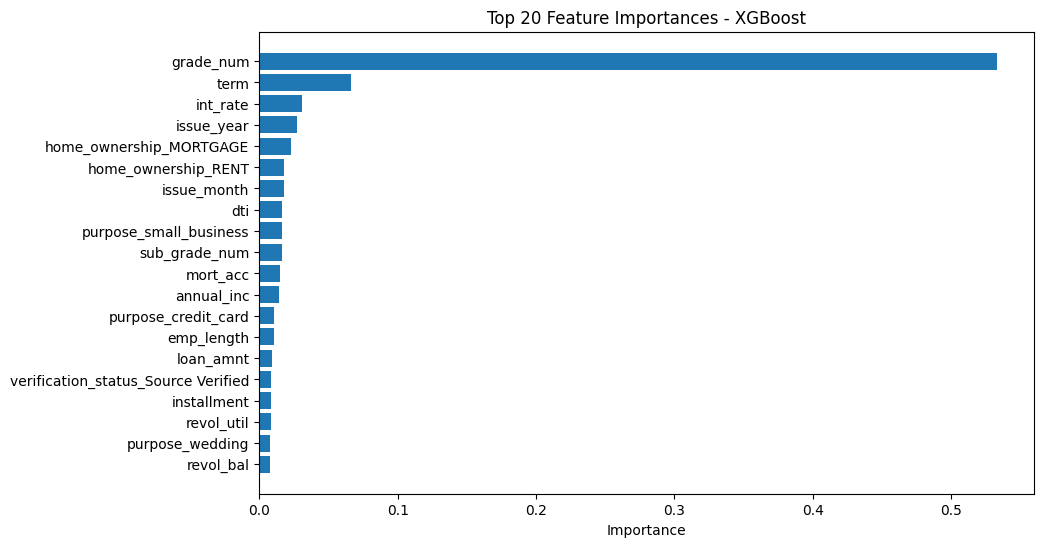

In [92]:
top_n = 20
top_features = xgb_importance.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances - XGBoost")
plt.show()

In [93]:
explainer = shap.TreeExplainer(xgb_model)

In [94]:
X_shap = X_test.sample(1000, random_state=42)

In [95]:
shap_values = explainer.shap_values(X_shap)

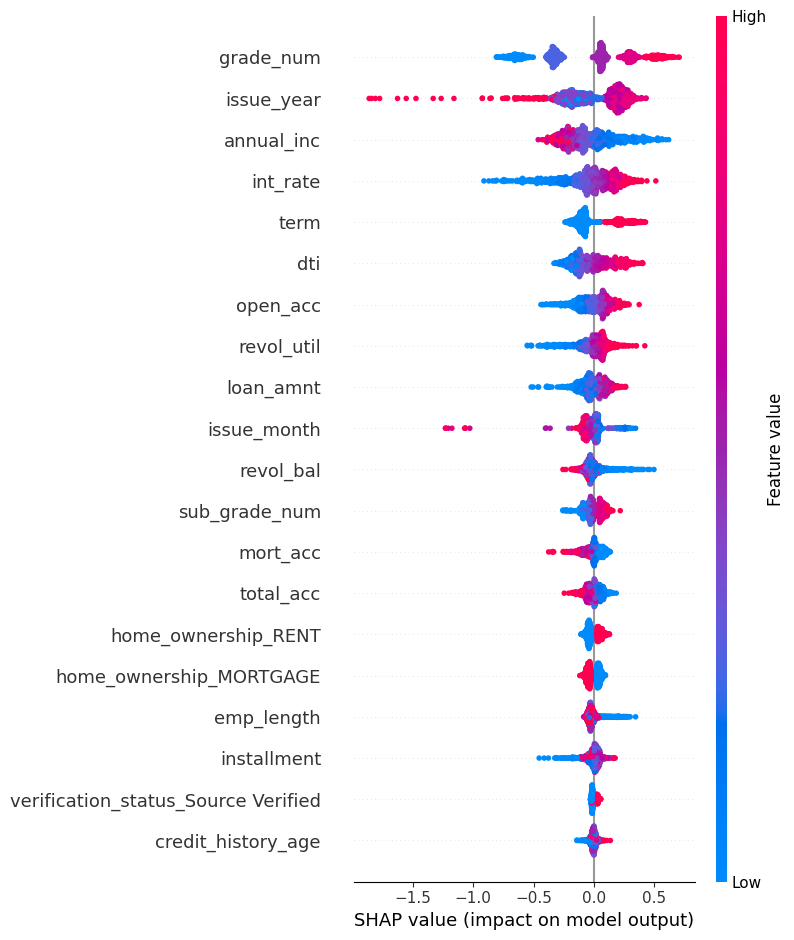

In [96]:
shap.summary_plot(shap_values, X_shap)

In [97]:
idx = 0
sample_row = X_shap.iloc[[idx]]

print("Predicted probability of default:", xgb_model.predict_proba(sample_row)[:, 1][0])

Predicted probability of default: 0.3756401


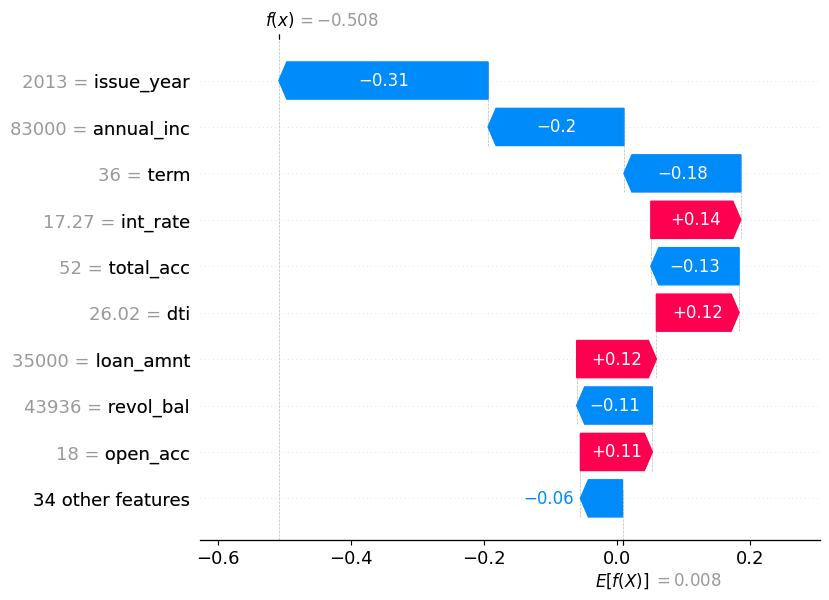

In [98]:
sample_shap = explainer(sample_row)
shap.plots.waterfall(sample_shap[0])

In [99]:
def risk_category(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Medium Risk"
    return "High Risk"

In [100]:
import joblib

joblib.dump(xgb_model, "credit_risk_xgboost.pkl")
joblib.dump(X_train.columns.tolist(), "xgb_feature_names.pkl")

print("XGBoost model saved.")

XGBoost model saved.
